In [5]:
from ultralytics import YOLO

import matplotlib.pyplot as plt
import matplotlib.image as mpimg 
import os
import numpy as np

import os
import supervision as sv
import cv2
import numpy as np

nr train frames: 138
i=0
920906195

image 1/1 /datasets/tdt4265/Poles2025/Road_poles_iPhone/images/Test/test/920906195.jpg: 1280x736 1 snowpole, 5.7ms
Speed: 2.4ms preprocess, 5.7ms inference, 0.6ms postprocess per image at shape (1, 3, 1280, 736)


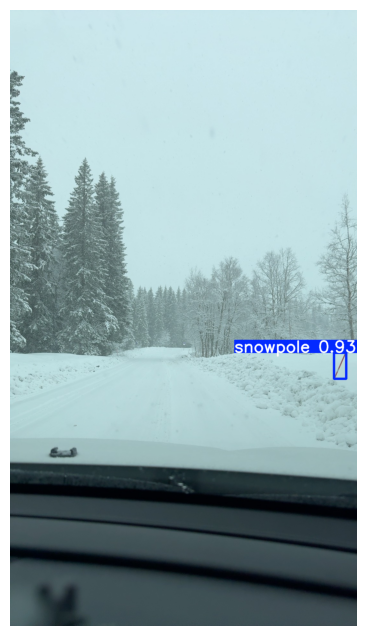

i=13
921520600

image 1/1 /datasets/tdt4265/Poles2025/Road_poles_iPhone/images/Test/test/921520600.jpg: 1280x736 1 snowpole, 5.7ms
Speed: 2.4ms preprocess, 5.7ms inference, 0.6ms postprocess per image at shape (1, 3, 1280, 736)


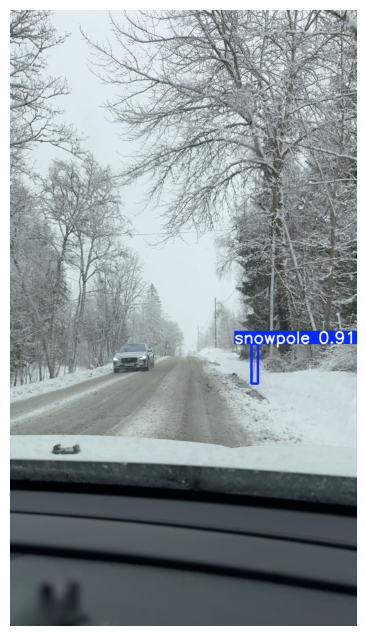

i=26
919947215

image 1/1 /datasets/tdt4265/Poles2025/Road_poles_iPhone/images/Test/test/919947215.jpg: 1280x736 1 snowpole, 5.7ms
Speed: 2.5ms preprocess, 5.7ms inference, 0.6ms postprocess per image at shape (1, 3, 1280, 736)


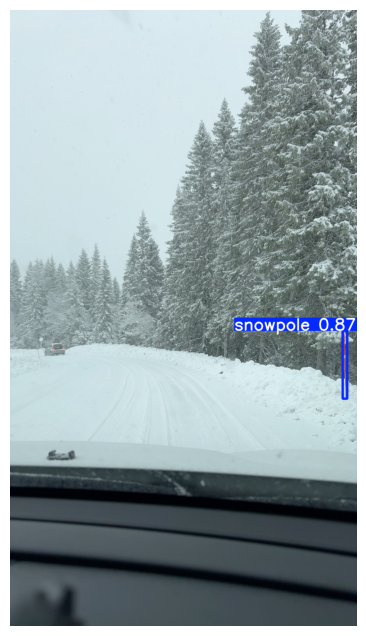

i=39
920217620

image 1/1 /datasets/tdt4265/Poles2025/Road_poles_iPhone/images/Test/test/920217620.jpg: 1280x736 1 snowpole, 5.7ms
Speed: 2.6ms preprocess, 5.7ms inference, 0.6ms postprocess per image at shape (1, 3, 1280, 736)


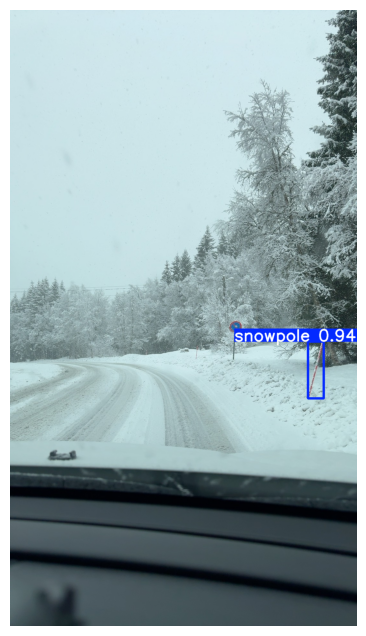

i=52
921364055

image 1/1 /datasets/tdt4265/Poles2025/Road_poles_iPhone/images/Test/test/921364055.jpg: 1280x736 1 snowpole, 5.7ms
Speed: 2.5ms preprocess, 5.7ms inference, 0.6ms postprocess per image at shape (1, 3, 1280, 736)


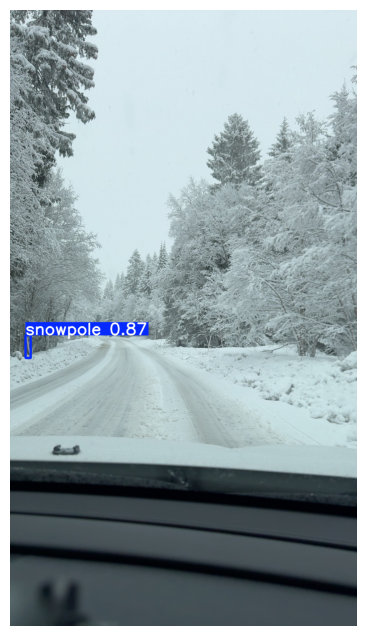

i=65
920878626

image 1/1 /datasets/tdt4265/Poles2025/Road_poles_iPhone/images/Test/test/920878626.jpg: 1280x736 1 snowpole, 5.3ms
Speed: 2.4ms preprocess, 5.3ms inference, 0.6ms postprocess per image at shape (1, 3, 1280, 736)


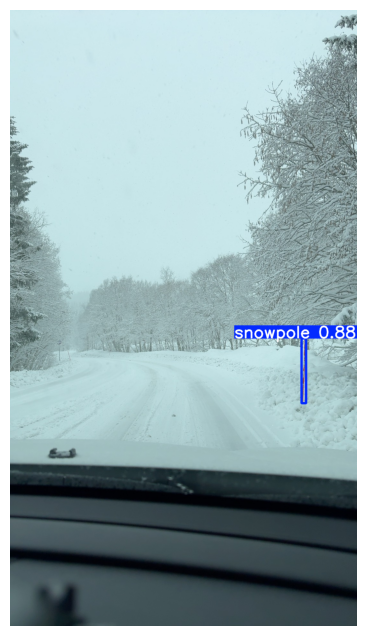

i=78
921240846

image 1/1 /datasets/tdt4265/Poles2025/Road_poles_iPhone/images/Test/test/921240846.jpg: 1280x736 1 snowpole, 5.5ms
Speed: 2.3ms preprocess, 5.5ms inference, 0.6ms postprocess per image at shape (1, 3, 1280, 736)


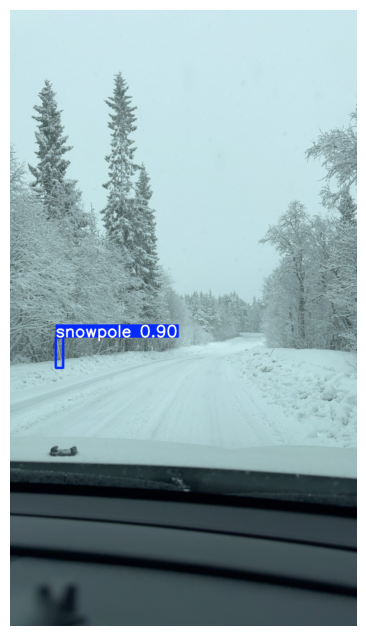

i=91
920702985

image 1/1 /datasets/tdt4265/Poles2025/Road_poles_iPhone/images/Test/test/920702985.jpg: 1280x736 2 snowpoles, 5.3ms
Speed: 2.4ms preprocess, 5.3ms inference, 0.8ms postprocess per image at shape (1, 3, 1280, 736)


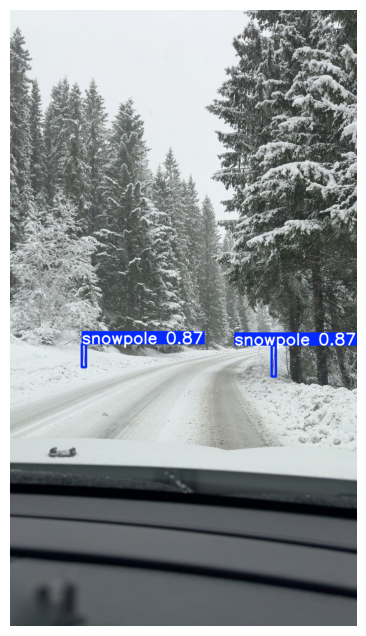

i=104
921487097

image 1/1 /datasets/tdt4265/Poles2025/Road_poles_iPhone/images/Test/test/921487097.jpg: 1280x736 1 snowpole, 5.3ms
Speed: 2.4ms preprocess, 5.3ms inference, 0.6ms postprocess per image at shape (1, 3, 1280, 736)


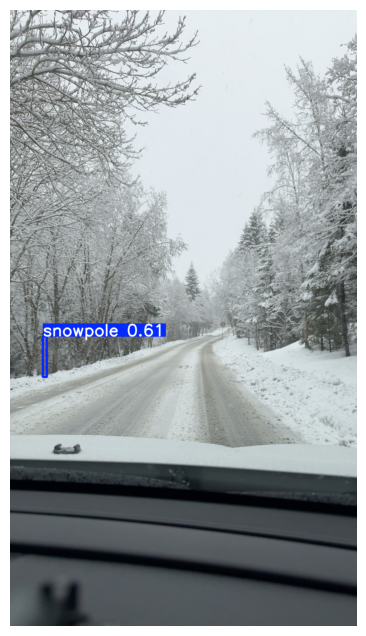

i=117
921335320

image 1/1 /datasets/tdt4265/Poles2025/Road_poles_iPhone/images/Test/test/921335320.jpg: 1280x736 1 snowpole, 5.3ms
Speed: 2.4ms preprocess, 5.3ms inference, 0.6ms postprocess per image at shape (1, 3, 1280, 736)


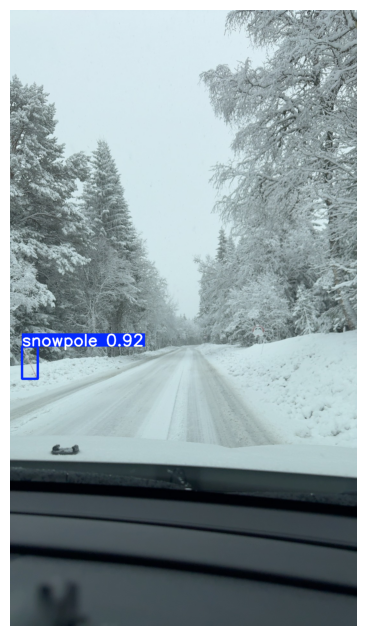

i=130
920693284

image 1/1 /datasets/tdt4265/Poles2025/Road_poles_iPhone/images/Test/test/920693284.jpg: 1280x736 2 snowpoles, 5.5ms
Speed: 2.4ms preprocess, 5.5ms inference, 0.7ms postprocess per image at shape (1, 3, 1280, 736)


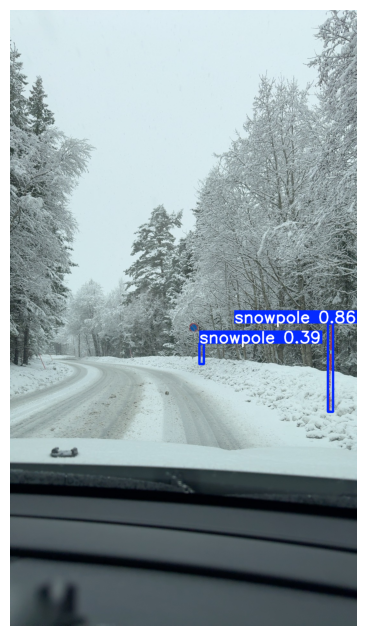

In [9]:
pt = "runs/detect/train17/weights/best.pt"

# # Load a pretrained YOLO11n model
model = YOLO(pt)


# Create a random numpy array of HWC shape (640, 640, 3) with values in range [0, 255] and type uint8
# source = np.random.randint(low=0, high=255, size=(640, 640, 3), dtype="uint8")

# Run inference on the source
#results = model(source)  # list of Results objects




# build dataset
train_img_folder_path = '/datasets/tdt4265/Poles2025/Road_poles_iPhone/images/Test/test' # .PNG
# train_img_folder_path = '/datasets/tdt4265/Poles2025/Road_poles_iPhone/images/Validation/val' # .PNG
#train_label_folder_path = '/datasets/tdt4265/Poles2025/Road_poles_iPhone/labels/Validation/val' # .txt
train_frames = []
for fname in os.listdir(train_img_folder_path):
    train_frames.append(fname[:-4])


nframes = len(train_frames); print('nr train frames:', nframes)
for i in range(0, nframes, nframes//10):
    frame = train_frames[i]
    print(f'{i=}')
    print(frame)
    img_path = os.path.join(train_img_folder_path, frame + '.jpg')
    label_path = os.path.join(train_label_folder_path, frame + '.txt')

    # predict
    results = model(img_path)
    for result in results:
        boxes = result.boxes  # Boxes object for bounding box outputs
        masks = result.masks  # Masks object for segmentation masks outputs
        keypoints = result.keypoints  # Keypoints object for pose outputs
        probs = result.probs  # Probs object for classification outputs
        obb = result.obb  # Oriented boxes object for OBB outputs
        #result.show()  # display to screen

        im_annotated = result.plot()   # draws boxes on a copy of the image

        # Show inline in the notebook
        plt.figure(figsize=(8, 8))
        plt.imshow(im_annotated[..., ::-1])  # BGR -> RGB for matplotlib
        plt.axis('off')
        plt.show()


    # gt
    # img = cv2.imread(img_path)         
    # h, w, _ = img.shape

    # yolo_boxes = np.array(
    #     [list(map(float, line.split()[1:5])) for line in open(label_path)],
    #     dtype=np.float32
    # )   # shape [N, 4] in (cx, cy, w, h) normalized

    # #print('boxes norm', yolo_boxes)
    # cx = yolo_boxes[:, 0] * w
    # cy = yolo_boxes[:, 1] * h
    # bw = yolo_boxes[:, 2] * w
    # bh = yolo_boxes[:, 3] * h

    # x1 = cx - bw / 2
    # y1 = cy - bh / 2
    # x2 = cx + bw / 2
    # y2 = cy + bh / 2
    
    # boxes_xyxy = np.stack([x1, y1, x2, y2], axis=1).astype(np.float32)
    # #print("boxes_xyxy:", boxes_xyxy)

    # # ---- 3) Build Detections (one class: 0) ----
    # class_ids = np.zeros(len(boxes_xyxy), dtype=int)
    # detections = sv.Detections(
    #     xyxy=boxes_xyxy,
    #     class_id=class_ids,
    # )

    # # ---- 4) Annotate ----
    # box_annotator = sv.BoxAnnotator(color=sv.Color.RED)
    # annotated_frame = box_annotator.annotate(scene=img, detections=detections)

    # sv.plot_image(annotated_frame)  # supervision handles BGR/RGB internally
    



In [1]:
/datasets/tdt4265/Poles2025/Road_poles_iPhone/images/Test/test

ls: cannot access 'source': No such file or directory
